#<h1><center>Lab 3 - A3</center></h1>

## Algoritmi evolutivi

Algoritmul evolutiv pentru problema rucsacului va fi implementat pe baza unei reprezentări binare,
repararea indivizilor care reprezintă soluţii nevalide (pentru a respecta capacitatea rucsacului) şi o
funcţie de fitness ce calculeaza valoarea totală pusă în rucsac (ce trebuie maximizată).
Algoritmul evolutiv pentru problema TSP va fi implementat pe baza unei reprezentări prin permutări,
folosirea unor operatori de încrucișare și mutaţie care generează soluţii valide și o funcţie de fitness
ce calculează distanţa totală parcursă (ce trebuie minimizată).
Componentele algoritmului sunt:
* Generare populaţie iniţială aleator (populaţie P).
* Selecţie părinţi.
* Generare descendenţi: încrucişare şi mutaţie (populaţie O).
* Selecţie supravieţuitori: cei mai buni size(P) din P+O.
* Parametri algoritm: mărimea populaţiei, numărul de generaţii, probabilitatea de încrucişare,
probabilitatea de mutaţie.


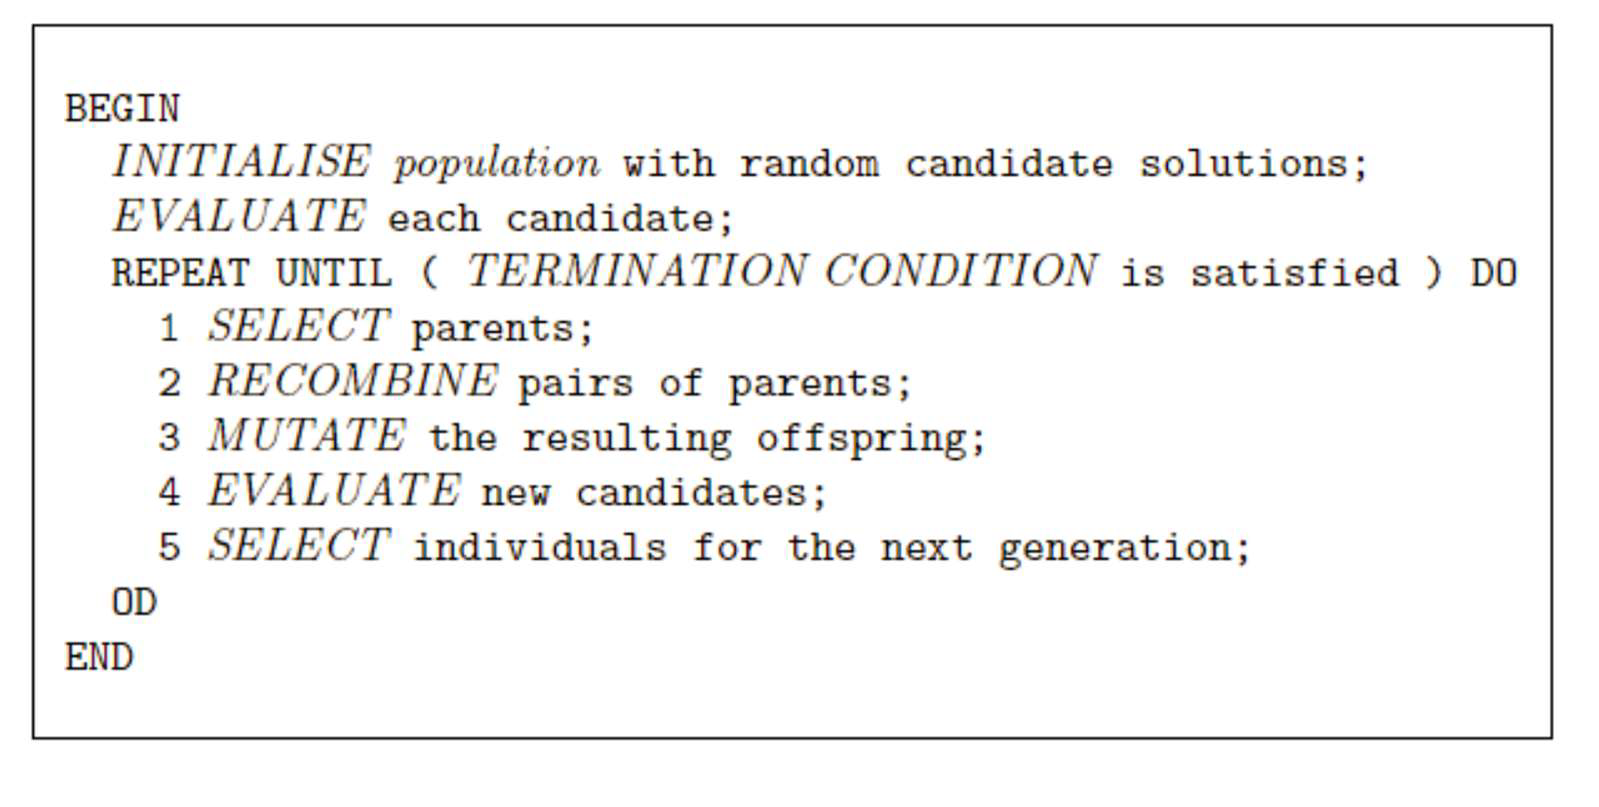

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time

##	Lucru în timpul laboratorului

1. Completarea de cod în fișierul Jupyter Notebook (A2.ipynb) unde este notat cu TODO:
 1. Selecție părinți
 1. Selecție generație următoare
 1. Implementare mutație pentru soluție cu codificare binară
 1. Implementare încrucișare pentru soluție cu codificare binară
 1. Completare algoritm evolutiv pentru codificare binară
 1. Implementare mutație pentru soluție cu codificare prin permutări
 1. Implementare încrucișare pentru soluție cu codificare prin permutări
 1. Completare algoritm evolutive pentru codificare prin permutări
 1. Implementare funcție pentru codificare reală

**Total Punctaj A3-Lab = 60p**

**Deadline Lab 3**

### Funcții problema rucsacului

#### Încărcare de date

In [ ]:
# definire încărcare date
def load_data_rucsac(file_name: str) -> "tuple[list[tuple[int, int]], int]":
  """
  Citeste datele din fisierul file_name
  """
  weights_and_values = []
  with open(file_name) as f:
    nr_obj = int(f.readline())
    for i in range(nr_obj):
      line = f.readline()
      line = line.split(" ")
      line = [x for x in line if x != ""]
      weights_and_values.append(tuple(int(x) for x in line[1:]))
    max_capacity = int(f.readline())
  return weights_and_values, max_capacity
load_data_rucsac("/content/rucsac-200.txt") # rucsac-20.txt and rucsac-200.txt

([(835, 735),
  (1670, 1470),
  (3340, 2940),
  (1087, 987),
  (1087, 987),
  (517, 417),
  (1034, 834),
  (2068, 1668),
  (1034, 834),
  (630, 530),
  (1260, 1060),
  (1260, 1060),
  (1071, 971),
  (165, 65),
  (330, 130),
  (495, 195),
  (176, 76),
  (663, 563),
  (1326, 1126),
  (1326, 1126),
  (984, 884),
  (1968, 1768),
  (2952, 2652),
  (829, 729),
  (1658, 1458),
  (3316, 2916),
  (829, 729),
  (663, 563),
  (1326, 1126),
  (1989, 1689),
  (1086, 986),
  (1086, 986),
  (639, 539),
  (1278, 1078),
  (2556, 2156),
  (1917, 1617),
  (895, 795),
  (1790, 1590),
  (3580, 3180),
  (888, 788),
  (1776, 1576),
  (3552, 3152),
  (2664, 2364),
  (232, 132),
  (464, 264),
  (928, 528),
  (464, 264),
  (472, 372),
  (944, 744),
  (691, 591),
  (1382, 1182),
  (2764, 2364),
  (1052, 952),
  (1052, 952),
  (1057, 957),
  (2114, 1914),
  (2114, 1914),
  (456, 356),
  (912, 712),
  (651, 551),
  (1302, 1102),
  (1953, 1653),
  (711, 611),
  (1422, 1222),
  (1042, 942),
  (232, 132),
  (464, 264

#### Formarea unei soluții, vecinătate și fitness

In [ ]:
# definire funcții de fitness/evaluare și generare

def is_valid_rucsac(objects: list, sol: list, max_capacity: int):
  """
  Verifica validitatea unei solutii
  """
  weight = 0
  i = 0
  while i < len(sol) and weight <= max_capacity:
    weight += objects[i][1] * sol[i]
    i += 1
  return weight <= max_capacity

def random_neighbor_rucsac(sol: list):
  """
  Generează un vecin aleatoriu pentru o soluție
  """
  x = sol[:]
  index = np.random.randint(len(sol))
  x[index] = 1 - x[index]
  return x

def generate_solution_rucsac(n: int):
  """
  Genereaza o solutie aleatoare
  """
  return list(np.random.randint(2, size=n))


def generate_valid_solution_rucsac(n: int, objects: list, max_capacity: int):
  """
  Genereaza o solutie valida aleatoare
  INPUT
  ------
  n: numarul de obiecte
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  sol: soluția generată
  """
  stop = False
  sol = []
  while not stop:
    sol = generate_solution_rucsac(n)
    stop = is_valid_rucsac(objects, sol, max_capacity)
  return sol

def fitness_rucsac(objects: list, sol: list, max_capacity: int):
  """
  Evaluează o soluție pentru problema rucsacului.
  INPUT
  ------
  objects: obiectele care pot fi adăugate în rucsac
  sol: solutția drept o listă de 0 și 1 de lungimea numărului de obiecte
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  value: valoarea tutoror obiectelor care au fost adăugate în rucsac
        sau -1 dacă greutatea obiectelor trece peste greutatea maximă permisă
  """
  value = 0
  if not is_valid_rucsac(objects, sol, max_capacity):
    return -1

  for i in range(len(sol)):
      value += objects[i][0] * sol[i]
  return value

# Cod pentru testarea funcțiilor pentru rucsac
o, m = load_data_rucsac("/content/rucsac-200.txt")
sol = generate_valid_solution_rucsac(len(o), o, m)
print(sol)
print(fitness_rucsac(o, sol, m))
n = random_neighbor_rucsac(sol)
print(n)
print(fitness_rucsac(o, n, m))

[np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0)

### Funcții TSP

#### Încărcare de date

In [ ]:
def read_from_file_TSP(name: str) -> "tuple[list[tuple], int]":
  """
  Citeste datele din fisierul name pentru problema TSP
  INPUT
  -----
  name: numele fisierului
  OUTPUT
  ------
  locations: lista de locații sub forma (index, x, y)
  dimension: dimensiunea problemei
  """
  locations = []
  dimension = 0
  with open(name, 'r') as file:
    for i in range(6):
      line = file.readline()
      line = line.replace("\n", "")
      line = line.split(" ")
      if len(line) == 2 and line[0] == "DIMENSION:":
        dimension = int(line[1])
    for i in range(dimension):
      line = file.readline()
      line = line.replace("\n", "")
      line = line.split(" ")
      line = [x for x in line if x != ""]
      locations.append(tuple(int(x) for x in line[:]))
  return locations, dimension

def read_from_file_TSPOpt(name: str):
  """
  Citeste solutia din fisierul name pentru problema TSP
  INPUT
  -----
  name: numele fisierului
  OUTPUT
  ------
  solution: lista de locații sub forma de index
  """
  solution = []
  dimension = 0
  with open(name, 'r') as file:
    for i in range(5):
      line = file.readline()
      line = line.replace("\n", "")
      line = line.split(" ")
      if len(line) == 3 and line[0] == "DIMENSION":
        dimension = int(line[2])
    for i in range(dimension):
      line = file.readline()
      line = line.replace("\n", "")
      solution.append(int(line) - 1)
  return solution

read_from_file_TSP("/content/kroC100.tsp")
#read_from_file_TSP("/content/kroC100.opt.tour")

([(1, 1357, 1905),
  (2, 2650, 802),
  (3, 1774, 107),
  (4, 1307, 964),
  (5, 3806, 746),
  (6, 2687, 1353),
  (7, 43, 1957),
  (8, 3092, 1668),
  (9, 185, 1542),
  (10, 834, 629),
  (11, 40, 462),
  (12, 1183, 1391),
  (13, 2048, 1628),
  (14, 1097, 643),
  (15, 1838, 1732),
  (16, 234, 1118),
  (17, 3314, 1881),
  (18, 737, 1285),
  (19, 779, 777),
  (20, 2312, 1949),
  (21, 2576, 189),
  (22, 3078, 1541),
  (23, 2781, 478),
  (24, 705, 1812),
  (25, 3409, 1917),
  (26, 323, 1714),
  (27, 1660, 1556),
  (28, 3729, 1188),
  (29, 693, 1383),
  (30, 2361, 640),
  (31, 2433, 1538),
  (32, 554, 1825),
  (33, 913, 317),
  (34, 3586, 1909),
  (35, 2636, 727),
  (36, 1000, 457),
  (37, 482, 1337),
  (38, 3704, 1082),
  (39, 3635, 1174),
  (40, 1362, 1526),
  (41, 2049, 417),
  (42, 2552, 1909),
  (43, 3939, 640),
  (44, 219, 898),
  (45, 812, 351),
  (46, 901, 1552),
  (47, 2513, 1572),
  (48, 242, 584),
  (49, 826, 1226),
  (50, 3278, 799),
  (51, 86, 1065),
  (52, 14, 454),
  (53, 1327, 1

#### Formarea unei soluții, vecinătate și fitness

In [ ]:
def distance_matrix_TSP(locations: list):
  """
  Formarea matricei de distanțe pe baza datelor încărcate
  """
  length = len(locations)
  dm = np.zeros([length, length], dtype=int)
  for i in range(length):
    for j in range(i + 1, length):
      xd = locations[i][1] - locations[j][1]
      yd = locations[i][2] - locations[j][2]
      dm[i][j] = int(round(np.sqrt(xd * xd + yd * yd)))
      dm[j][i] = dm[i][j]
  return dm

def generate_solution_TSP(dimension: int):
  """
  Generează o soluție aleatoare pentru problema TSP sub forma unei permutari
  """
  return list(np.random.permutation(dimension))

def fitness_TSP(solution: list, dm: "list[list]"):
  """
  Determina fitness-ul unei soluții pentru problema TSP
  """
  distance = 0
  for i in range(len(solution)):
    if i != len(solution) - 1:
      distance += dm[solution[i]][solution[i + 1]]
    else:
      distance += dm[solution[i]][solution[0]]
  return distance

def two_swap(solution: list, dimension: int):
  """
  Generează un vecin aleatoriu pentru o soluție prin metoda 2-swap
  """
  x = solution[:]
  i = no.random.randint(dimension)
  j = no.random.randint(dimension)
  while j == i:
    j = no.random.randint(dimension)
  x[i], x[j] = x[j], x[i] #ERA O GRESEALA DE SCRIERE
  return x

def two_opt(solution: list, i: int, j: int):
  x = solution[:]
  index = 0
  while i + index < j - index:
    x[i + index], x[j - index] = x[j - index], x[i + index]
    index += 1
  return x

### Algorimi evolutivi

#### Generare populatie

In [ ]:
def generate_rnd_population_knapsack(population_size: int, problem_size: int, objects: "list[tuple]", max_capacity: int):
  """
  Returneaza o populatie de marime population_size pentru problema rucsacului de marime problem_size
  INPUT
  ------
  population_size: marimea populatiei
  problem_size: marimea pentru solutia problemei
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  population: populatia noua pentru problema specificata
  """
  population = []
  for i in range(population_size):
    population.append(generate_valid_solution_rucsac(problem_size, objects, max_capacity))
  return population

def generate_rnd_population_TSP(problem_size: int, population_size: int):
  """
  Returneaza o populatie de marime population_size pentru TSP de marime problem_size
  INPUT
  ------
  population_size: marimea populatiei
  problem_size: marimea pentru solutia problemei
  OUTPUT
  ------
  population: populatia noua pentru problema specificata
  """
  population = []
  for i in range(population_size):
    population.append(generate_solution_TSP(problem_size))
  return population

#### Selectie parinti

In [ ]:
#@title Codificare binara
def selection_kanpsack(population: list, population_size: int, objects: "list[tuple]", max_capacity: int):
  """
  Aici se selecteaza un parinte din populatia initiala. Se foloseste selectia turnir de marime 5.
  """
  parents = [None, None]
  p = population[:]  # copie a populatiei initiale
  for i in range(2):
    sample = sorted(np.random.default_rng().choice(population_size, size=5, replace=False),
                    reverse=True)
    possible_parents = [p[s] for s in sample]
    for j in range(len(sample)): #AM SCHIMBAT DIN i IN j
      del p[sample[j]]
    population_size -= 5 # Ne asigurăm că un membru din populație nu e selectat de două ori

    possible_parents = sorted(possible_parents, key=lambda x: fitness_rucsac(objects, x, max_capacity),
                              reverse=True) # TODO: Înlocuiește None cu valorile corecte
    parents[i] = possible_parents[0] # TODO: Atribuie cel mai bun părinte
  return parents[0], parents[1] # TODO: Returnează cei mai buni 2 părinți găsiți în interații diferite

In [ ]:
#@title Codificare prin permutari
def selection_TSP(population: list, population_size: int, dm: "list[list[int]]"):
  """
  Aici se selecteaza un parinte din populatia initiala. Se foloseste selectia turnir de marime 5.
  """
  parents = [None, None]
  p = population[:]  # copie a populatiei initiale
  for i in range(2):
    sample = sorted(np.random.default_rng().choice(population_size, size=5, replace=False),
                    reverse=True)
    possible_parents = [p[s] for s in sample]
    for j in range(len(sample)): #AM SC
      del p[sample[j]]
    population_size -= 5 # Ne asigurăm că un membru din populație nu e selectat de două ori

    possible_parents = sorted(possible_parents, key=lambda x: fitness_TSP(x, dm),
                              reverse=False) # TODO: Înlocuiește None cu valorile corecte
    parents[i] = possible_parents[0] # TODO: Atribuie cel mai bun părinte
  return parents[0], parents[1] # TODO: Returnează cei mai buni 2 părinți găsiți în interații diferite

#### Incrucisare si mutatie

In [ ]:
#@title Codificare binara

def binary_crossover(population_size: int, population: list, crossover_count: int,
                     objects: "list[tuple]", max_capacity: int):
  """
  Aici se executa un crossover in pentru populație
  INPUT
  -----
  population_size: mărimea populației
  population: populația din care se obțin părinții și copii
  crossover_count: numărul de încrucișări
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  -----
  children - soluții copil obținute după încrucișare
  """
  children = []
  for i in range(crossover_count):
    parent1, parent2 = selection_kanpsack(population, population_size, objects, max_capacity)# TODO: Selectare parintii din populatie
    child1, child2 = [], []
    # TODO: Aplicare algortim de încrucișare la alegere
    cut_point = np.random.randint(1, len(parent1))
    child1 = parent1[:cut_point] + parent2[cut_point:]
    child2 = parent2[:cut_point] + parent1[cut_point:]
    children.append(child1)
    children.append(child2)
  return children

def binary_mutation(children: list, problem_size: int, mutation_rate: float):
  """
  Aici se execută algoritmul de mutație
  """
  mutanted_children = []
  for c in children:
    mutated_child = c[:]
    if np.random.random() < mutation_rate:
      # TODO: Aplicare algoritm de mutație la alegere
      i = np.random.randint(problem_size)
      mutated_child[i] = 1 - mutated_child[i]
    mutanted_children.append(mutated_child)
  return mutanted_children


In [ ]:
#@title Codificare prin permutari

def permutation_crossover(population_size: int, population: list, crossover_count: int,
                          dm: "list[list[int]]"):
  """
  Aici se executa un crossover in pentru populație
  INPUT
  -----
  population_size: mărimea populației
  population: populația din care se obțin părinții și copii
  crossover_count: numărul de încrucișări
  dm: matricea de distanțe
  OUTPUT
  -----
  children - soluții copil obținute după încrucișare
  """
  children = []
  for i in range(crossover_count):
    parent1, parent2 = selection_TSP(population, population_size, dm)# TODO: Selectare parintii din populatie
    child1, child2 = [], []
    # TODO: Aplicare algortim de încrucișare la alegere
    parent1_size = len(parent1)
    start, end =sorted(np.random.choice(parent1_size, 2, replace = False))

    section1 = parent1[start:end]
    rest_section1 = [x for x in parent2 if x not in section1]
    child1 = rest_section1[:start] + section1 + rest_section1[start:]

    section2 = parent2[start:end]
    rest_section2 = [x for x in parent1 if x not in section2]
    child2 = rest_section2[:start] + section2 + rest_section2[start:]

    children.append(child1)
    children.append(child2)
  return children

def permutation_mutation(children: list, problem_size: int, mutation_rate: float):
  """
  Aici se execută algoritmul de mutație
  """
  mutanted_children = []
  for c in children:
    mutated_child = c[:]
    if np.random.random() < mutation_rate:
      # TODO: Aplicare algoritm de mutație la alegere
      i, j = np.random.choice(problem_size, 2, replace=False)
      mutated_child[i], mutated_child[j] = mutated_child[j], mutated_child[i]
    mutanted_children.append(mutated_child)
  return mutanted_children

#### Populatia urmatoare

In [ ]:
#@title Codificare binara
def make_it_valid_rucsac(objects: "list[tuple]", sol: "list[int]", max_capacity: int):
  """
  Transformarea unei solutii invalide intr-o solutie valida
  """
  length = len(sol)
  repaired_solution = sol[:]
  i = 0
  while i < length:
    if repaired_solution[i] == 1:
        repaired_solution[i] = 0
    if is_valid_rucsac(objects, repaired_solution, max_capacity):
        return repaired_solution
    i += 1
  return repaired_solution # Returnează soluția corectată în caz că nu s-a făcut în while

def new_population(old_population: list, mutated_children: list, objects: "list[tuple]", max_capacity: int):
    """
    Genereaza o populatie noua dupa urmatoarele reguli:
    -se pastreaza toti copiii obtinuti dupa mutatie
    -locurile libere din populatie se vor umple cu parintii ramasi
    """
    population = []
    mc = mutated_children[:]
    for i in range(len(mc)):
        if not is_valid_rucsac(objects, mc[i], max_capacity):
            mc[i] = mc[i] # TODO: Folosiți funcția de mai sus pentru corectare
    population = old_population + mc
    population = population # TODO: Sortarea populației în funcție de fitness
    population = population[:len(old_population)] # Reducerea poulației la cele mai bune valori
    return population

In [ ]:
#@title Codificare prin permutari
def new_population(old_population: list, mutated_children: list, dm: "list[list[int]]"):
    """
    Genereaza o populatie noua dupa urmatoarele reguli:
    -se pastreaza toti copiii obtinuti dupa mutatie
    -locurile libere din populatie se vor umple cu parintii ramasi
    """
    population = []
    mc = mutated_children[:]
    population = old_population + mc
    population = sorted(population, key=lambda x:fitness_TSP(x, dm), reverse = False) # TODO: Sortarea populației în funcție de fitness
    population = population[:len(old_population)] # Reducerea poulației la cele mai bune valori
    return population

In [ ]:
def new_population_knapsack(old_population: list, mutated_children: list, objects: list, max_capacity: int):
    mc = mutated_children[:]
    for i in range(len(mc)):
        if not is_valid_rucsac(objects, mc[i], max_capacity):
            mc[i] = make_it_valid_rucsac(objects, mc[i], max_capacity) # Folosim funcția de reparare

    combined = old_population + mc
    # Sortăm descrescător după fitness (cel mai mare e mai bun)
    combined.sort(key=lambda x: fitness_rucsac(objects, x, max_capacity), reverse=True)
    return combined[:len(old_population)]

#### Structura de baza a algoritmului evolutiv

In [ ]:
#@title Codificare binara
def evaluate_population_knapsack(population_size: int, population: list, problem_size: int, objects: "list[tuple]", max_capacity: int):
  """
  Evaluarea populatiei si returnarea best, average si worst fitness
  """
  best, avg, worst = 0, 0, 0
  eval_population = sorted(population, key=lambda x: fitness_rucsac(objects, x, max_capacity), reverse=True)
  best = fitness_rucsac(objects, eval_population[0], max_capacity)
  avg = avg = sum(fitness_rucsac(objects, x, max_capacity) for x in population) / population_size
  worst = fitness_rucsac(objects, eval_population[-1], max_capacity)
  return best, avg, worst

def evolutionary_algorithm_knapsack(population_size: int, mutation_rate: float, crossover_rate: float, generations: int,
                                    problem_size: int, objects: "list[tuple]", max_capacity: int):
  """
  Aceasta functie executa un algoritm evolutiv
  INPUT
  -----
  population_size: marimea populatiei pe parcursul problemei
  mutation_rate: rata de mutatie (sansele de a face mutatii asupra unei solutii)
  crossover_rate: rata populatiei obtinute din crossover (nu va afecta obtinerea populatiei initiale)
  generations: numarul de generatii parcurse de algoritm pana la stop
  problem_size: marimea problemei (adica cat de lungi o sa fie solutiile obtinute)
  objects: obiectele care pot fi adăugate în rucsac
  max_capacity: capacitatea maximă a rucsacului
  OUTPUT
  ------
  best: cele mai bune fitness-uri din populatie
  avg: valoarile medii pentru fitness-urile populatie
  worst: cele mai slabe fitness-uri din populatie
  """
  population = generate_rnd_population_knapsack(population_size, problem_size, objects, max_capacity) # TODO: Apelare algoritm pentru generarea popuției inițiale
  b, a, w = evaluate_population_knapsack(population_size, population, problem_size, objects, max_capacity) # TODO: Apelare algoritm de evaluare a problemei
  best = [b]
  avg = [a]
  worst = [w]
  crossover_count = int((population_size * crossover_rate) // 2)
  for i in range(generations):
    mutants = []
    children = binary_crossover(population_size, population, crossover_count, objects, max_capacity) # TODO: Apelare algoritm de încrucișare
    mutants = binary_mutation(children, problem_size, mutation_rate) # TODO Apelare algoritm de mutație
    population = new_population_knapsack(population, mutants, objects, max_capacity) # TODO: Apelare algoritm pentru generația nouă new_population(problem_type, population, mutants, evaluator)
    b, a, w = evaluate_population_knapsack(population_size, population, problem_size, objects, max_capacity) # TODO: Apelare algoritm de evaluare a problemei
    best.append(b)
    avg.append(a)
    worst.append(w)
  return best, avg, worst

In [ ]:
#@title Codificare prin permutari
#AM MODIFICAT EU NUMELE
def evaluate_population_tsp(population_size: int, population: list, problem_size: int, dm: "list[list[int]]"):
  """
  Evaluarea populatiei si returnarea best, average si worst fitness
  """
  best, avg, worst = 0, 0, 0
  eval_population = sorted(population, key=lambda x: fitness_TSP(x, dm), reverse=False)
  best = fitness_TSP(eval_population[0], dm)
  avg = sum(fitness_TSP(x, dm) for x in population) / population_size
  worst = fitness_TSP(eval_population[-1], dm)
  return best, avg, worst

def evolutionary_algorithm_tsp(population_size: int, mutation_rate: float, crossover_rate: float, generations: int,
                               problem_size: int, dm: "list[list[int]]"):
  """
  Aceasta functie executa un algoritm evolutiv
  INPUT
  -----
  population_size: marimea populatiei pe parcursul problemei
  mutation_rate: rata de mutatie (sansele de a face mutatii asupra unei solutii)
  crossover_rate: rata populatiei obtinute din crossover (nu va afecta obtinerea populatiei initiale)
  generations: numarul de generatii parcurse de algoritm pana la stop
  problem_size: marimea problemei (adica cat de lungi o sa fie solutiile obtinute)
  dm: matricea de distante
  OUTPUT
  ------
  best: cele mai bune fitness-uri din populatie
  avg: valoarile medii pentru fitness-urile populatie
  worst: cele mai slabe fitness-uri din populatie
  """
  population = generate_rnd_population_TSP(problem_size, population_size) # TODO: Apelare algoritm pentru generarea popuției inițiale
  b, a, w = evaluate_population_tsp(population_size, population, problem_size, dm) # TODO: Apelare algoritm de evaluare a problemei
  best = [b]
  avg = [a]
  worst = [w]
  crossover_count = int((population_size * crossover_rate) // 2)
  for i in range(generations):
    mutants = []
    children = permutation_crossover(population_size, population, crossover_count, dm) # TODO: Apelare algoritm de încrucișare
    mutants = permutation_mutation(children, problem_size, mutation_rate) # TODO Apelare algoritm de mutație
    population = new_population(population, mutants, dm) # TODO: Apelare algoritm pentru generația nouă new_population(problem_type, population, mutants, evaluator)
    b, a, w = evaluate_population_tsp(population_size, population, problem_size, dm) # TODO: Apelare algoritm de evaluare a problemei
    best.append(b)
    avg.append(a)
    worst.append(w)
  return best, avg, worst

In [ ]:
# Knapsack
o, m = load_data_rucsac("/content/rucsac-200.txt")

best_k, avg_k, worst_k = evolutionary_algorithm_knapsack(
    population_size=50,
    mutation_rate=0.1,
    crossover_rate=0.8,
    generations=100,
    problem_size=len(o),
    objects=o,
    max_capacity=m
)

print("=== Knapsack ===")
print(f"Best:  {best_k[-1]}")
print(f"Avg:   {avg_k[-1]:.2f}")
print(f"Worst: {worst_k[-1]}")

# TSP
locations, dimension = read_from_file_TSP("/content/kroC100.tsp")
dm = distance_matrix_TSP(locations)

best_t, avg_t, worst_t = evolutionary_algorithm_tsp(
    population_size=50,
    mutation_rate=0.1,
    crossover_rate=0.8,
    generations=100,
    problem_size=dimension,
    dm=dm
)

print("\n=== TSP ===")
print(f"Best:  {best_t[-1]}")
print(f"Avg:   {avg_t[-1]:.2f}")
print(f"Worst: {worst_t[-1]}")

=== Knapsack ===
Best:  132511
Avg:   132511.00
Worst: 132511

=== TSP ===
Best:  89142
Avg:   89791.40
Worst: 89872


### Funcție codificare reală

In [ ]:
def function_real_coding():
  # TODO: Implementare funcție conform document teams
  pass

## A3 - Temă

1. Implementare algoritm evolutive pentru codificare reală:
2. Implementare PSO pentru codificare reală sau ACO pentru TSP
3. Scrierea de documentație drept un Jupyter Notebook sau un document word/pdf
 * Documentare cod
 * Explicarea funcțiilor pe pași
 * Tabel cu rezultate pentru fiecare instanță a problemei prentru minim 5 valori diferite
de parametri
    * Incluzând tabele cu rezultate pentru algoritmi implementați la lab
 * Vizualizare rezultate între interații
 * Analiza rezultatelor
    * Comparație între toți algoritmii anteriori pentru aceiași problemă

**Total Punctaj A3-Temă= 60p**

**Deadline Lab 4**

**Functia Ackley - problema 10 din lista**
- contine un minim global foarte bine evidentiat;
- are mai multe minime locale ceea ce face ca algoritmii sa se opreasca in acestea (sa se blocheze).

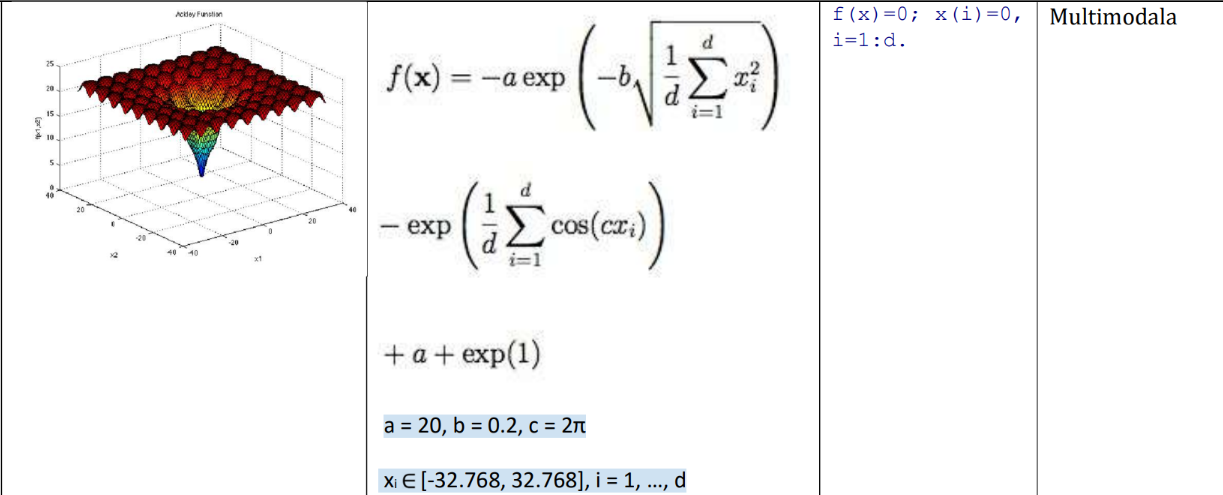

**Definirea Functiei Ackley**

In [2]:
def ackley_function(x):
  a = 20
  b = 0.2
  c = 2*np.pi
  d = len(x)

  sum1 = np.sum(x**2)
  sum2 = np.sum(np.cos(c*x))
  t1 = -a*np.exp(-b*np.sqrt(sum1/d))
  t2 = -np.exp(sum2/d)

  return t1 + t2 + a + np.exp(1)

**Implementare functii necesare - Algoritm evolutiv pentru functia Ackley**

In [3]:
def generate_population(population_size, n):
  '''
  Functie care construieste populatia initiala sub forma unui
  vector de n elemente cu valori in intervalul problemei.
  -----
  INPUT
  population_size: numarul de indivizi din populatie
  n: cele n elemente ale vectorului de reprezentare a problemei
  -------
  OUTPUT
  vectorul de indivizi din intervalul problemei.
  '''
  return [
      np.array([random.uniform(-32.768, 32.768) for _ in range(n)])
      for _ in range(population_size)
    ]


def fitness(sol):
  '''
  Functie care evealueaza cat de buna este o solutie.
  ------
  INPUT
  sol: solutia evaluata
  ------
  OUTPUT:
  fitness-ul unei solutii
  '''
  return ackley_function(sol)


def tournament_selection(population, k=3):
  '''
  Functie care selecteaza cei mai buni indivizi dintr-o populatie
  printr-o metoda determinista care consta in sortarea indivizilor
  in functie de fitness si alecerea celui mai bun. In cazul acesta
  pe cel cu fitness-ul cel mai mic (problema de minimizare a functiei).
  ------
  INPUT
  population: intreaga populatie de unde se face selectia
  k: numarul de indivizi alesi
  ------
  OUTPUT
  selected[0]: cel mai bun individ
  '''
  selected = random.sample(population, k)
  selected.sort(key=fitness)
  return selected[0]


def crossover_discret(parent1, parent2, p=0.5):
  '''
  Functie probabilistica de incrucisare pentru a determina copiii noii generatii.
  ------
  INPUT
  parent1: primul parinte care ia parte la incrucisare
  parent2: al doilea parinte care ia parte la incrucisare
  p: probabilitatea care decide cat vor lua copiii de la parintele 1, restul
  fiind de la parintele 2
  ------
  OUTPUT
  Copiii rezultati in iurma incrucisarii.
  '''
  child1, child2 = [], []

  for i in range(len(parent1)):
    if random.random() < p:
      child1.append(parent1[i])
      child2.append(parent2[i])
    else:
      child1.append(parent2[i])
      child2.append(parent1[i])

  return np.array(child1), np.array(child2)


def mutation(child):
  '''
  Functie care realizeaza mutatia pentru a asigura explorarea populatiei.
  ------
  INPUT
  child: copilul care va suferi modificarea
  ------
  OUTPUT
  child: copilul modificat
  '''
  i = random.randint(0, len(child)-1)
  child[i] = random.uniform(-32.768, 32.768)
  return child

**Algoritm evolutiv functia Ackley**

In [9]:
def evolutionary_algorithm_ackley(population_size, n, generations, crossover_prob, mutation_prob, elitism_size):
  '''
  Functie pentru algoritmul evolutiv al functiei ackley care urmeaza pasii:
  -initializarea populatiei
  -pentru fiecare generatie: sortare, pastrarea elitelor, generearea copiilor (selectie,
  incrucisare si mutatie), actualizarea celui mai bun
  ------
  INPUT
  population_size: dimensiunea populatiei
  n: cele n elemente ale vectorului pentru prima populatie generata
  generations: generatiile din populatie
  crossover_prob: probabilitatea de incrucisare
  mutation_prob: probabilitatea de mutatie
  elitism_size: dimensiunea indivizilor elitisti
  ------
  OUTPUT
  best_sol: cel mai bun individ
  best_fitness: cel mai bun fitness
  history: istoricul intre iteratii
  '''
  population = generate_population(population_size, n)

  best_sol = None
  best_fitness = float("inf")
  history = []

  for generation in range(generations):

    population.sort(key=fitness)

    elites = population[:elitism_size]
    new_population = elites.copy()

    if fitness(population[0]) < best_fitness:
      best_fitness = fitness(population[0])
      best_sol = population[0]

    history.append(best_fitness)

    while len(new_population) < population_size:

      parent1 = tournament_selection(population)
      parent2 = tournament_selection(population)

      if random.random() < crossover_prob:
        child1, child2 = crossover_discret(parent1, parent2)
      else:
        child1, child2 = parent1.copy(), parent2.copy()

      if random.random() < mutation_prob:
        child1 = mutation(child1)

      if random.random() < mutation_prob:
        child2 = mutation(child2)

      new_population.append(child1)

      if len(new_population) < population_size:
        new_population.append(child2)

    population = new_population

  return best_sol, best_fitness, history

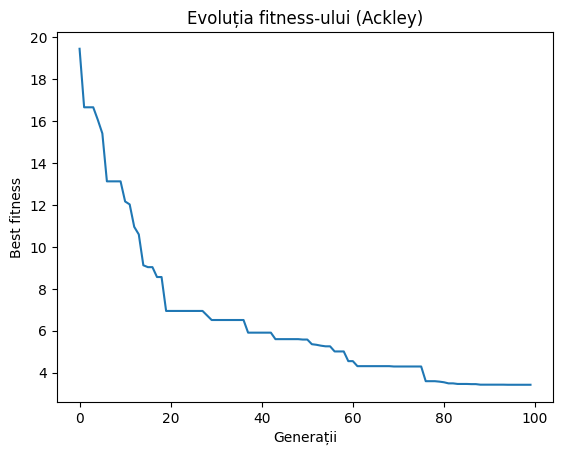

In [5]:
best_sol, best_fitness, history = evolutionary_algorithm_ackley(50, 10, 100, 0.7, 0.3, 2)
plt.plot(history)
plt.title("Evoluția fitness-ului (Ackley)")
plt.xlabel("Generații")
plt.ylabel("Best fitness")
plt.show()

| Instanță | Populație | Generații | Best Fitness |
|----------|-----------|-----------|--------------|
| 1 | 30 | 100 | 4.508207 |
| 2 | 50 | 100 | 3.729442 |
| 3 | 50 | 150 | 2.529083 |
| 4 | 70 | 150 | 1.856385 |
| 5 | 100 | 200 | 0.850738 |

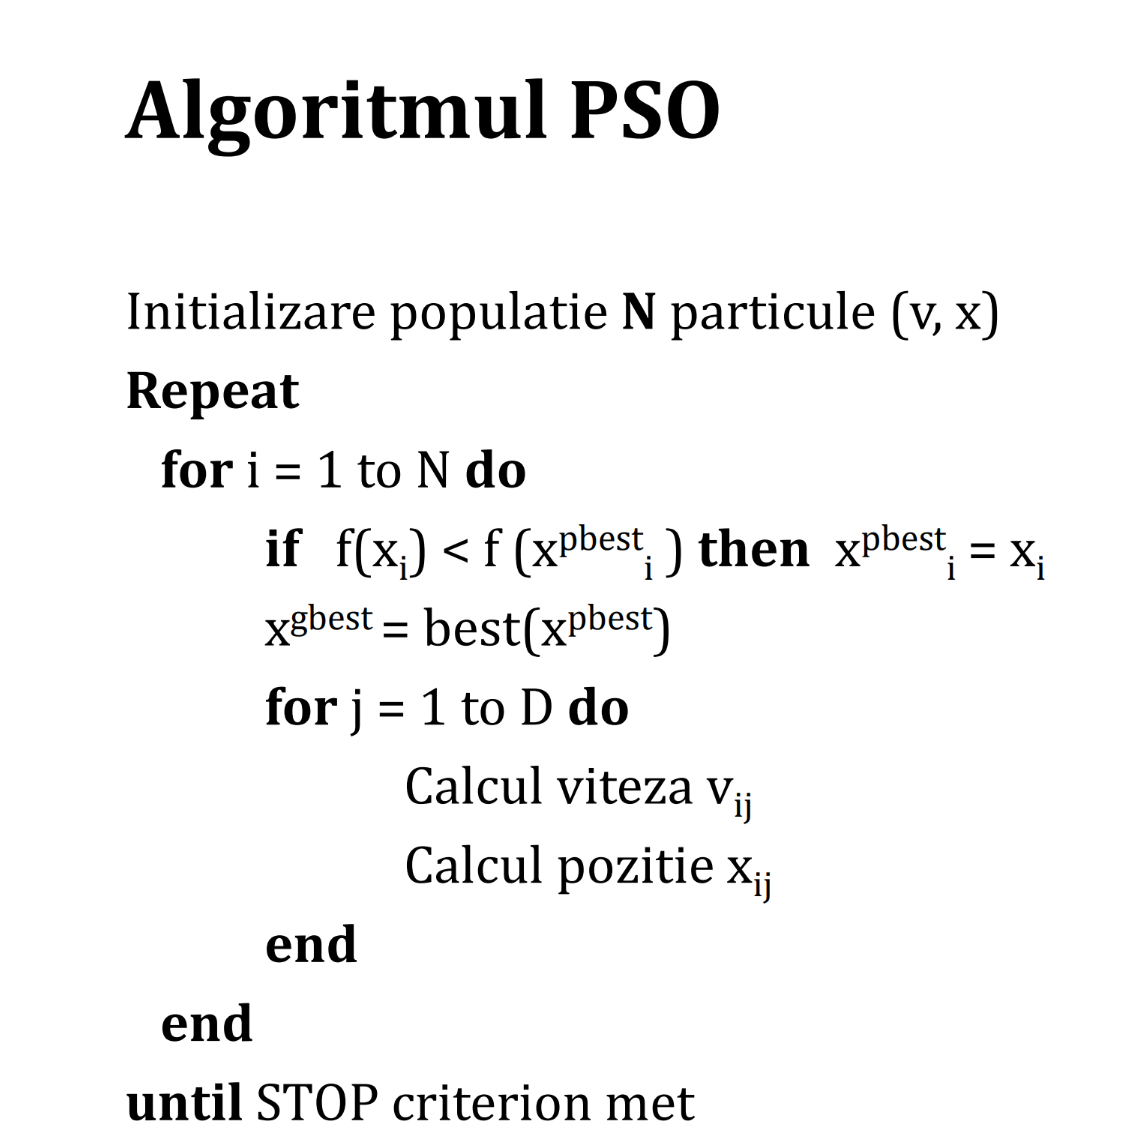

In [7]:
def pso_ackley_function(nr_particles, dim, max_iterations, w, c1, c2, bounds):
    '''
    Functie pentru algoritmul PSO al functiei ackley in face fiecare particula
    are o pozitie, viteza, memorie proprie (pbest) si memorie globala (gbest).
    Algoritmul initializeaza populatia, apoi pentru fiecare particula va genera
    doua numere random pentru a calcula viteza particulei. Apoi se verifica daca fitness-ul
    particulei este mai bun si se fac schimbarile necesare la nivel local,
    iar apoi se va alege minimul la nivel global. Algoritmul face si explorare
    si exploatare.
    ------
    INPUT
    nr_particles: cate particule sunt studiate
    dim: dimensiunea unei particule
    max_iterations: de cate ori este rulat algoritmul
    w: inertia unei particule, determina cat de mult se va explora
    c1: coeficientul cognitiv (atractia particulei fata de cea mai buna solutie locala)
    c2: coeficientul social (atractia particulei fata de cea mai buna solutie globala)
    bound: intervalul in care generam posibilele solutii (particulele)
    '''
    particles = np.random.uniform(bounds[0], bounds[1], (nr_particles, dim))
    velocities = np.zeros((nr_particles, dim))
    pbest = particles.copy()
    pbest_values = np.array([ackley_function(p) for p in particles])
    gbest = pbest[np.argmin(pbest_values)]
    gbest_values = min(pbest_values)
    history = []

    for i in range(max_iterations):
        for p in range(nr_particles):
            r1 = np.random.rand(dim)
            r2 = np.random.rand(dim)
            velocities[p] = (w * velocities[p] + c1 * r1 * (pbest[p] - particles[p]) + c2 * r2 * (gbest - particles[p]))
            particles[p] += velocities[p]
            particles[p] = np.clip(particles[p], bounds[0], bounds[1])

            fitness = ackley_function(particles[p])
            if fitness < pbest_values[p]:
                pbest[p] = particles[p]
                pbest_values[p] = fitness

        gbest = pbest[np.argmin(pbest_values)]
        gbest_values = min(pbest_values)

        history.append(gbest_values)

    return gbest, gbest_values, history

Text(0, 0.5, 'Best Fitness')

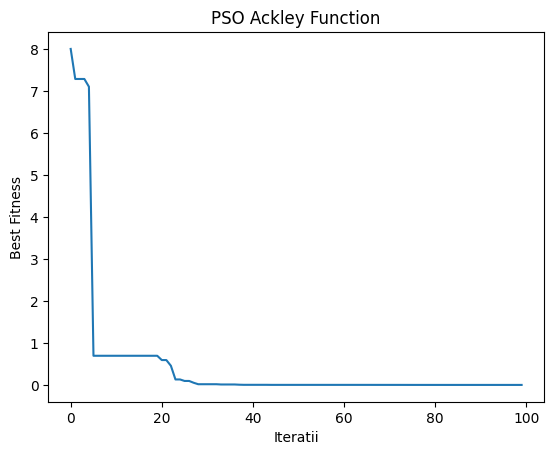

In [8]:
best_pos, best_val, history = pso_ackley_function(20, 2, 100, 0.7, 1.5, 1.5, (-32.768, 32.768))
plt.plot(history)
plt.title("PSO Ackley Function")
plt.xlabel("Iteratii")
plt.ylabel("Best Fitness")

| Instanță | Nr Particule | Iterații | Best Fitness |
|----------|-------------|----------|--------------|
| 1 | 30 | 100 | 0.116524 |
| 2 | 50 | 100 | 0.014888 |
| 3 | 50 | 150 | 0.000563 |
| 4 | 70 | 150 | 0.000404 |
| 5 | 100 | 200 | 0.000003 |

| Instanță | Pop/Particule | Iterații | EA Best Fitness | PSO Best Fitness |
|----------|---------------|----------|-----------------|------------------|
| 1 | 30 | 100 | 4.508207 | 0.116524 |
| 2 | 50 | 100 | 3.729442 | 0.014888 |
| 3 | 50 | 150 | 2.529083 | 0.000563 |
| 4 | 70 | 150 | 1.856385 | 0.000404 |
| 5 | 100 | 200 | 0.850738 | 0.000003 |
| Instanță | Populație | Generații | Best Fitness |
|----------|-----------|-----------|--------------|
| 1 | 30 | 100 | 4.508207 |
| 2 | 50 | 100 | 3.729442 |
| 3 | 50 | 150 | 2.529083 |
| 4 | 70 | 150 | 1.856385 |
| 5 | 100 | 200 | 0.850738 |
| Instanță | Nr Particule | Iterații | Best Fitness |
|----------|-------------|----------|--------------|
| 1 | 30 | 100 | 0.116524 |
| 2 | 50 | 100 | 0.014888 |
| 3 | 50 | 150 | 0.000563 |
| 4 | 70 | 150 | 0.000404 |
| 5 | 100 | 200 | 0.000003 |


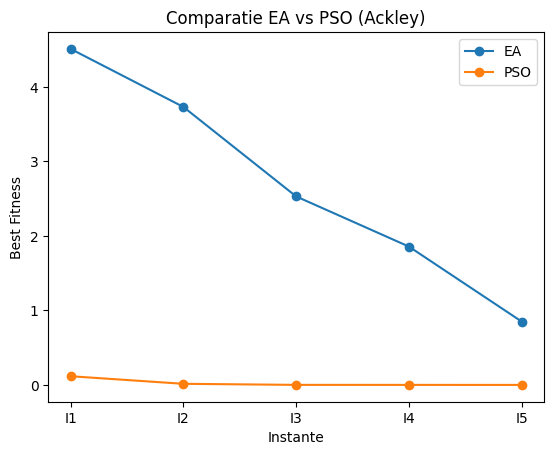

In [11]:
param_sets = [
    (30, 10, 100),
    (50, 10, 100),
    (50, 10, 150),
    (70, 10, 150),
    (100, 10, 200)
]

def run_ea(params, runs=3):
    results = []
    for _ in range(runs):
        _, best_fit, _ = evolutionary_algorithm_ackley(
            params[0], params[1], params[2],
            0.8, 0.2, 2
        )
        results.append(best_fit)
    return sum(results) / len(results)


def run_pso(params, runs=3):
    results = []
    for _ in range(runs):
        _, best_fit, _ = pso_ackley_function(
            params[0], params[1], params[2],
            0.7, 1.5, 1.5,
            (-32.768, 32.768)
        )
        results.append(best_fit)
    return sum(results) / len(results)

results = []

for i, params in enumerate(param_sets):
    ea_result = run_ea(params)
    pso_result = run_pso(params)

    results.append((i+1, params[0], params[2], ea_result, pso_result))

print("| Instanță | Pop/Particule | Iterații | EA Best Fitness | PSO Best Fitness |")
print("|----------|---------------|----------|-----------------|------------------|")

for r in results:
    print(f"| {r[0]} | {r[1]} | {r[2]} | {r[3]:.6f} | {r[4]:.6f} |")

print("| Instanță | Populație | Generații | Best Fitness |")
print("|----------|-----------|-----------|--------------|")

for r in results:
    print(f"| {r[0]} | {r[1]} | {r[2]} | {r[3]:.6f} |")

print("| Instanță | Nr Particule | Iterații | Best Fitness |")
print("|----------|-------------|----------|--------------|")

for r in results:
    print(f"| {r[0]} | {r[1]} | {r[2]} | {r[4]:.6f} |")

import matplotlib.pyplot as plt

ea_vals = [r[3] for r in results]
pso_vals = [r[4] for r in results]
labels = [f"I{r[0]}" for r in results]

plt.plot(labels, ea_vals, marker='o', label="EA")
plt.plot(labels, pso_vals, marker='o', label="PSO")

plt.title("Comparatie EA vs PSO (Ackley)")
plt.xlabel("Instante")
plt.ylabel("Best Fitness")
plt.legend()
plt.show()


*   Se poate observa si in tabel ca PSO merge mai rapid catre minimul global comparativ cu algoritmul evolutiv pentru functia Ackley.
*   AE ofera explorare mai buna, insa necesita un numar mai mare de generatii pentru a descoperii soltii in proximitatea optimului.

**PSO este mai stabil si mai eficient in acest caz**

| Instanță | Pop/Particule | Iterații | EA Best Fitness | PSO Best Fitness |
|----------|---------------|----------|-----------------|------------------|
| 1 | 30 | 100 | 4.508207 | 0.116524 |
| 2 | 50 | 100 | 3.729442 | 0.014888 |
| 3 | 50 | 150 | 2.529083 | 0.000563 |
| 4 | 70 | 150 | 1.856385 | 0.000404 |
| 5 | 100 | 200 | 0.850738 | 0.000003 |